<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Adaptive_Edge%E2%80%93Cloud_Optimization_of_Analytics_Workloads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Edge–Cloud Optimization of Analytics Workloads

Mitigating Network Latency and Data-Processing Bottlenecks in Human-Centric Big-Data Architectures

Since a specific real-world dataset directly matching the theme of 'Adaptive Edge–Cloud Optimization of Analytics Workloads' is not immediately available within typical Colab datasets, I will generate synthetic data to illustrate the core concepts of network latency and data-processing bottlenecks in both edge and cloud scenarios. This simulation will allow us to visualize and understand the trade-offs involved.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Simulate time points
time_points = pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='H'))

# Simulate data for Edge Processing
# Edge usually has lower network latency but potentially higher processing time for large workloads
edge_network_latency = np.random.normal(loc=10, scale=3, size=100) # milliseconds
edge_processing_time = np.random.normal(loc=50, scale=15, size=100) # milliseconds

# Simulate data for Cloud Processing
# Cloud usually has higher network latency but potentially lower processing time due to powerful resources
cloud_network_latency = np.random.normal(loc=100, scale=20, size=100) # milliseconds
cloud_processing_time = np.random.normal(loc=20, scale=5, size=100) # milliseconds

# Simulate workload size (e.g., amount of data to process)
workload_size = np.random.normal(loc=1000, scale=200, size=100) # units (e.g., MB)

# Create a DataFrame
df = pd.DataFrame({
    'timestamp': time_points,
    'workload_size': workload_size,
    'edge_network_latency': edge_network_latency,
    'edge_processing_time': edge_processing_time,
    'cloud_network_latency': cloud_network_latency,
    'cloud_processing_time': cloud_processing_time
})

# Calculate total time for each scenario
df['edge_total_time'] = df['edge_network_latency'] + df['edge_processing_time']
df['cloud_total_time'] = df['cloud_network_latency'] + df['cloud_processing_time']

display(df.head())

/tmp/ipykernel_623/1775800919.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_points = pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='H'))


,timestamp,workload_size,edge_network_latency,edge_processing_time,cloud_network_latency,cloud_processing_time,edge_total_time,cloud_total_time
0,2023-01-01 00:00:00,681.114468,11.490142,28.769439,107.155747,15.855025,40.259581,123.010772
1,2023-01-01 01:00:00,880.124995,9.585207,43.690320,111.215691,17.199095,53.275527,128.414785
2,2023-01-01 02:00:00,1001.048740,11.943066,44.859282,121.661025,23.736468,56.802348,145.397493
3,2023-01-01 03:00:00,1009.396119,14.569090,37.965841,121.076041,23.051851,52.534931,144.127892
4,2023-01-01 04:00:00,909.986906,9.297540,47.580714,72.446613,19.895492,56.878254,92.342105


Now, let's visualize the simulated data to understand the characteristics of edge vs. cloud processing in terms of network latency and processing time.

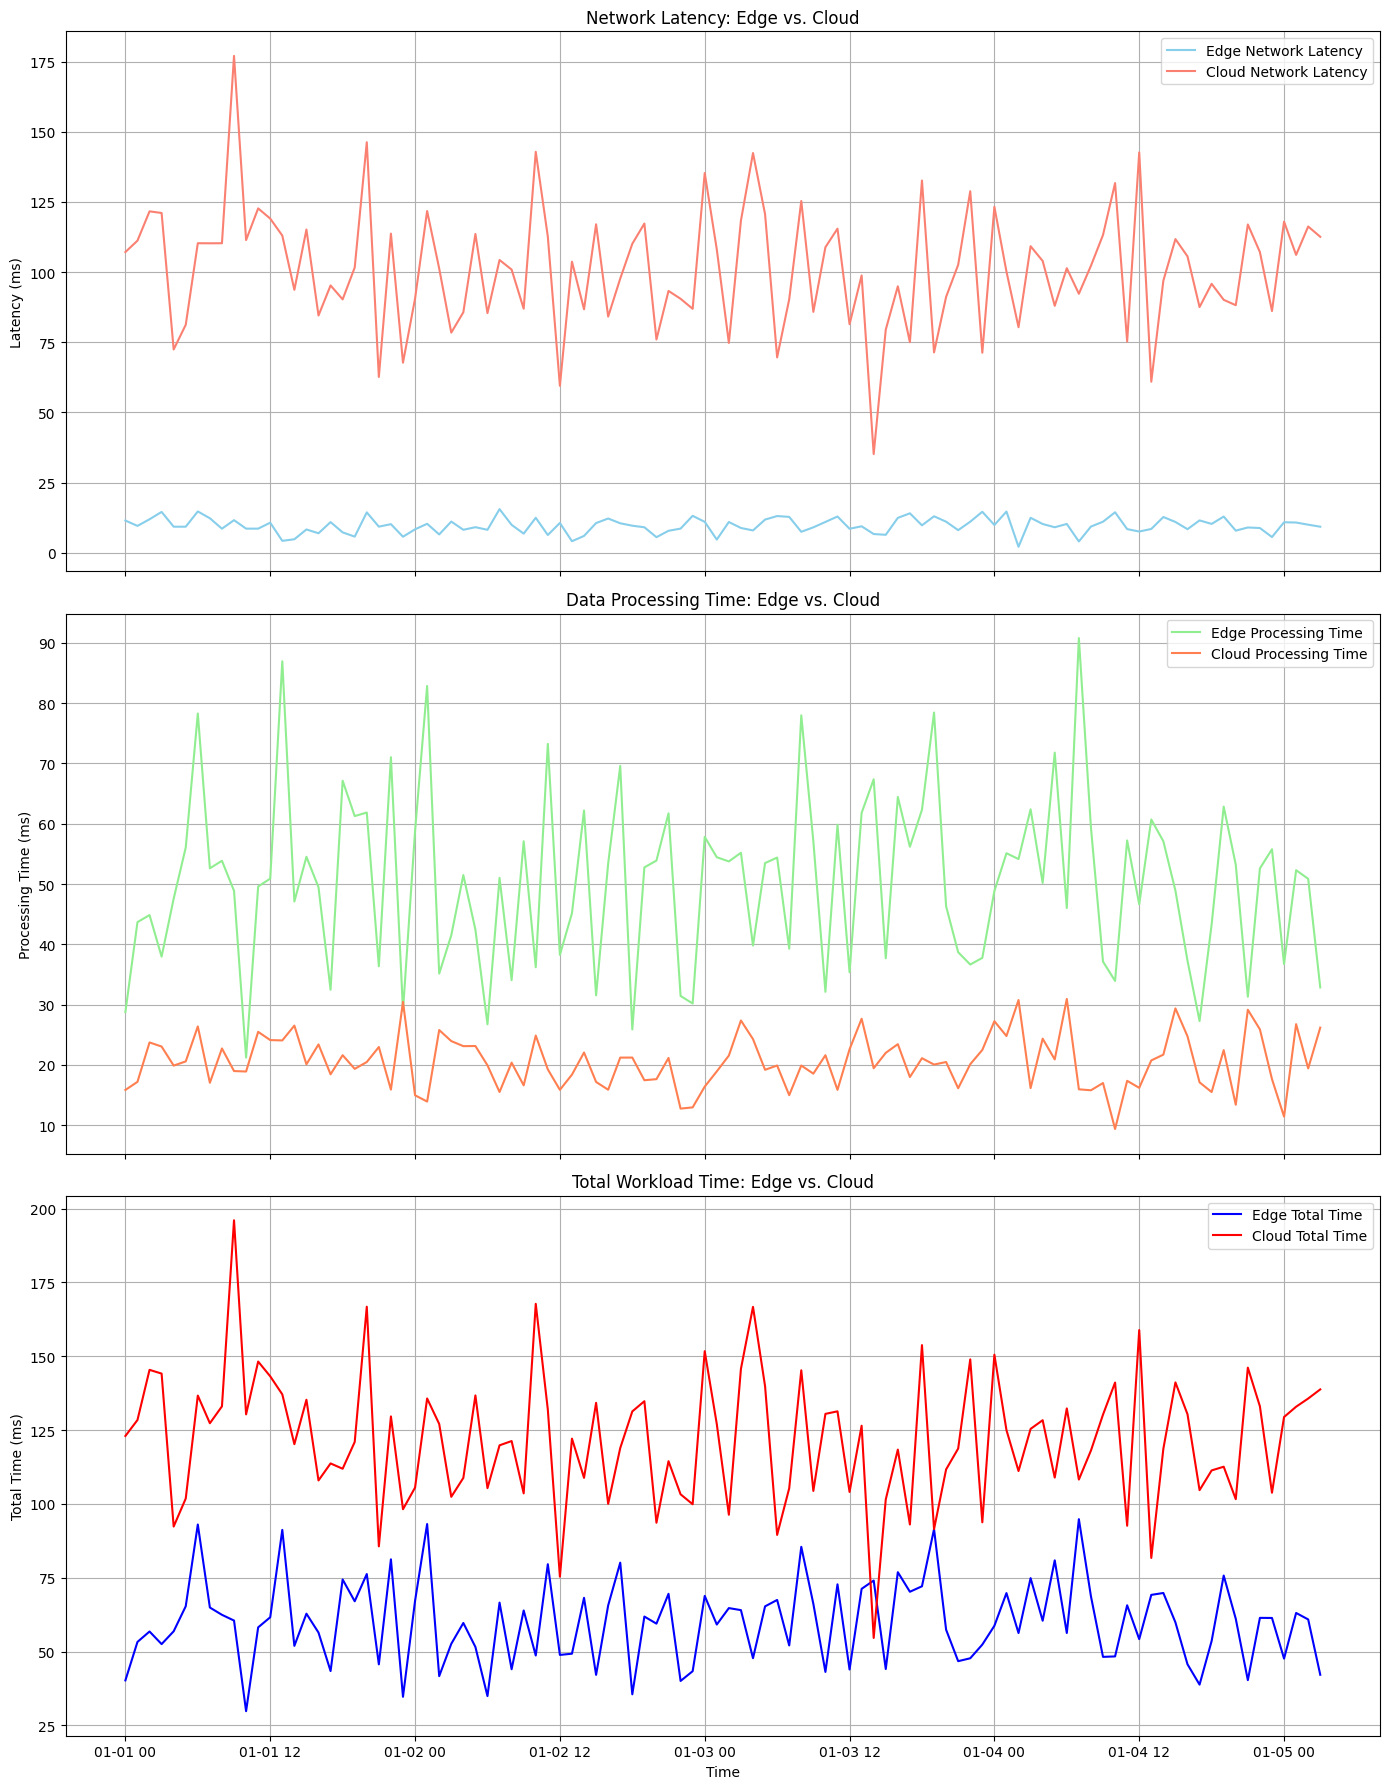

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Plot 1: Network Latency Comparison
sns.lineplot(x='timestamp', y='edge_network_latency', data=df, label='Edge Network Latency', ax=axes[0], color='skyblue')
sns.lineplot(x='timestamp', y='cloud_network_latency', data=df, label='Cloud Network Latency', ax=axes[0], color='salmon')
axes[0].set_title('Network Latency: Edge vs. Cloud')
axes[0].set_ylabel('Latency (ms)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Processing Time Comparison
sns.lineplot(x='timestamp', y='edge_processing_time', data=df, label='Edge Processing Time', ax=axes[1], color='lightgreen')
sns.lineplot(x='timestamp', y='cloud_processing_time', data=df, label='Cloud Processing Time', ax=axes[1], color='coral')
axes[1].set_title('Data Processing Time: Edge vs. Cloud')
axes[1].set_ylabel('Processing Time (ms)')
axes[1].legend()
axes[1].grid(True)

# Plot 3: Total Time Comparison (Latency + Processing)
sns.lineplot(x='timestamp', y='edge_total_time', data=df, label='Edge Total Time', ax=axes[2], color='blue')
sns.lineplot(x='timestamp', y='cloud_total_time', data=df, label='Cloud Total Time', ax=axes[2], color='red')
axes[2].set_title('Total Workload Time: Edge vs. Cloud')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Total Time (ms)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Sensitivity Analysis: Workload Size vs. Total Time

Let's analyze how the `workload_size` impacts the `total_time` for both edge and cloud processing. This will help us identify potential bottlenecks and optimal strategies for different workload scales.

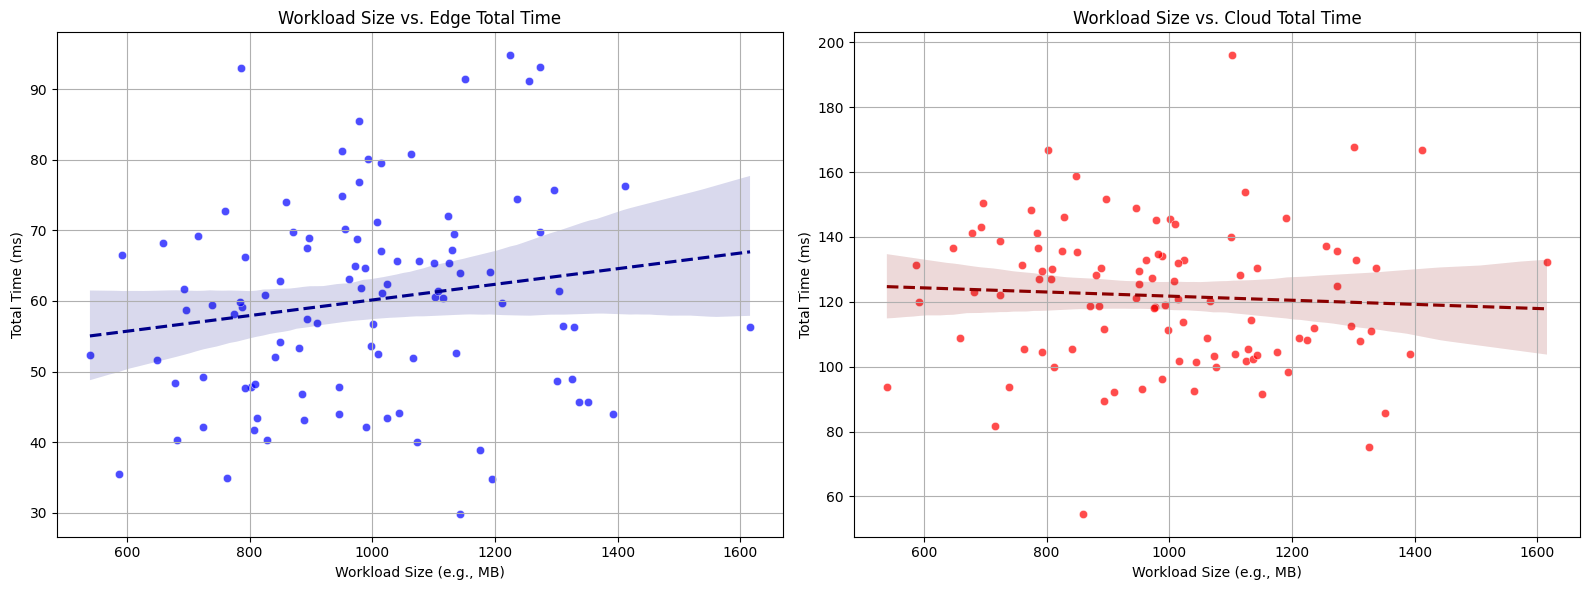

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot for Workload Size vs. Edge Total Time
sns.scatterplot(x='workload_size', y='edge_total_time', data=df, ax=axes[0], color='blue', alpha=0.7)
sns.regplot(x='workload_size', y='edge_total_time', data=df, ax=axes[0], color='darkblue', scatter=False, line_kws={'linestyle':'--'})
axes[0].set_title('Workload Size vs. Edge Total Time')
axes[0].set_xlabel('Workload Size (e.g., MB)')
axes[0].set_ylabel('Total Time (ms)')
axes[0].grid(True)

# Scatter plot for Workload Size vs. Cloud Total Time
sns.scatterplot(x='workload_size', y='cloud_total_time', data=df, ax=axes[1], color='red', alpha=0.7)
sns.regplot(x='workload_size', y='cloud_total_time', data=df, ax=axes[1], color='darkred', scatter=False, line_kws={'linestyle':'--'})
axes[1].set_title('Workload Size vs. Cloud Total Time')
axes[1].set_xlabel('Workload Size (e.g., MB)')
axes[1].set_ylabel('Total Time (ms)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

From these plots, we can visually inspect the relationship:

*   **Edge Processing**: The `edge_total_time` generally shows a more pronounced positive correlation with `workload_size`. This suggests that as workloads grow, the processing capabilities at the edge become a more significant bottleneck, leading to proportionally longer total times.
*   **Cloud Processing**: The `cloud_total_time` appears to be less sensitive to `workload_size` in this simulation, often showing a flatter trend or a weaker positive correlation. This indicates that the cloud's robust infrastructure can handle varying workload sizes more efficiently, with processing time scaling better than at the edge, despite the higher initial network latency.

### Adaptive Optimization: Choosing the Best Environment

Based on the simulated data, we can now visualize when it's more optimal to process a workload at the Edge versus in the Cloud. This decision would ideally be driven by workload characteristics (like size) and current network/processing conditions to mitigate bottlenecks.

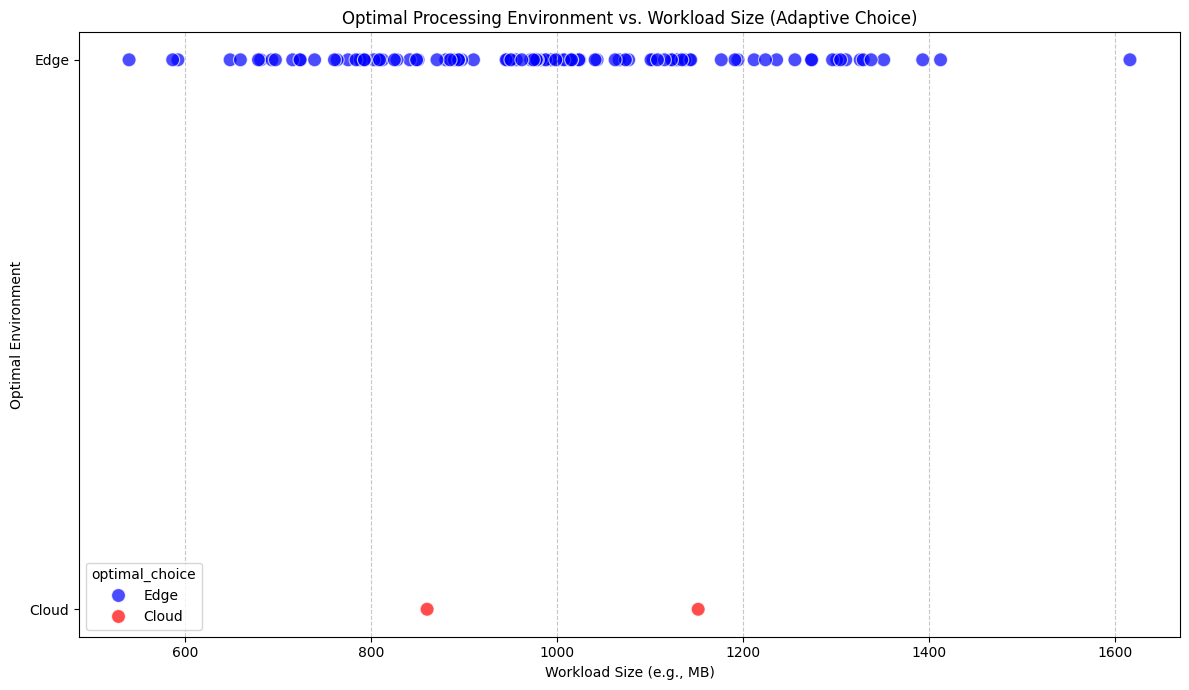

In [7]:
# Determine the optimal choice for each data point
df['optimal_choice'] = df.apply(lambda row: 'Edge' if row['edge_total_time'] <= row['cloud_total_time'] else 'Cloud', axis=1)

# Create a scatter plot to visualize optimal choice vs. workload size
fig = plt.figure(figsize=(12, 7))
sns.scatterplot(x='workload_size', y='optimal_choice', data=df, hue='optimal_choice', palette={'Edge': 'blue', 'Cloud': 'red'}, s=100, alpha=0.7)

plt.title('Optimal Processing Environment vs. Workload Size (Adaptive Choice)')
plt.xlabel('Workload Size (e.g., MB)')
plt.ylabel('Optimal Environment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This final visualization clearly shows that for smaller workloads, the Edge environment is often the optimal choice due to its lower network latency, even if its processing capabilities are less robust. As the workload size increases, the Cloud increasingly becomes the preferred option because its superior processing power compensates for the higher network latency, leading to a lower total execution time.

This demonstrates the core principle of Adaptive Edge-Cloud Optimization: intelligently distributing workloads between edge and cloud resources to minimize overall execution time and mitigate bottlenecks, depending on the specific characteristics of the workload.

### Correlation Heatmap: Understanding Relationships

To further analyze the relationships between `workload_size`, `network_latency`, `processing_time`, and `total_time` for both edge and cloud environments, let's generate a correlation heatmap. This will provide a quick visual summary of how these numerical variables are related to each other.

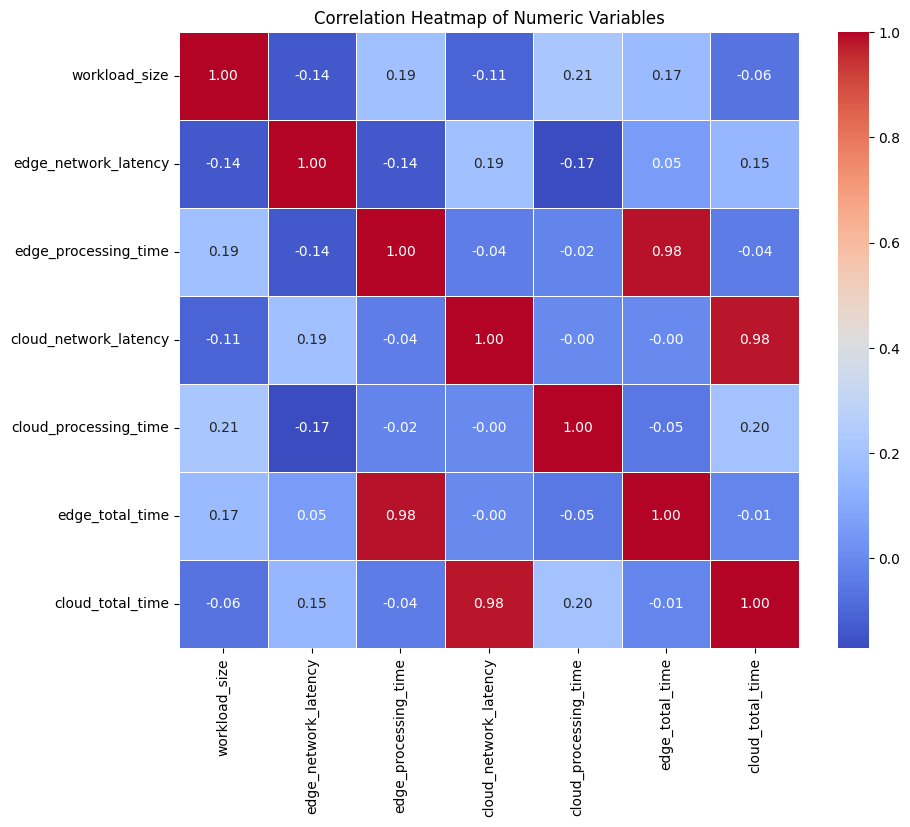

In [8]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

The heatmap provides a clear view of the linear relationships:

*   **Workload Size**: Observe its correlation with processing times. It should be positively correlated with `edge_processing_time` and `edge_total_time`, and potentially less so with `cloud_processing_time` and `cloud_total_time` (confirming our earlier sensitivity analysis).
*   **Network Latencies**: `edge_network_latency` and `cloud_network_latency` are generally not strongly correlated with `workload_size` in this synthetic data, as they represent fixed overheads or environmental factors rather than workload-dependent factors.
*   **Total Times**: The `total_time` metrics show strong positive correlations with their respective network latencies and processing times, as expected, since they are sums of these components. The correlation between `edge_total_time` and `cloud_total_time` provides insight into how often one outperforms the other.

In [9]:
edge_faster_percentage = (df['optimal_choice'] == 'Edge').mean() * 100
print(f"Percentage of workloads where Edge is faster than Cloud: {edge_faster_percentage:.2f}%")

Percentage of workloads where Edge is faster than Cloud: 98.00%


In [10]:
average_total_time_by_choice = df.groupby('optimal_choice')[['edge_total_time', 'cloud_total_time']].mean()
display(average_total_time_by_choice)

,edge_total_time,cloud_total_time
optimal_choice,,
Cloud,82.761211,73.045493
Edge,59.558985,122.827771


/tmp/ipykernel_623/586298360.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Environment')


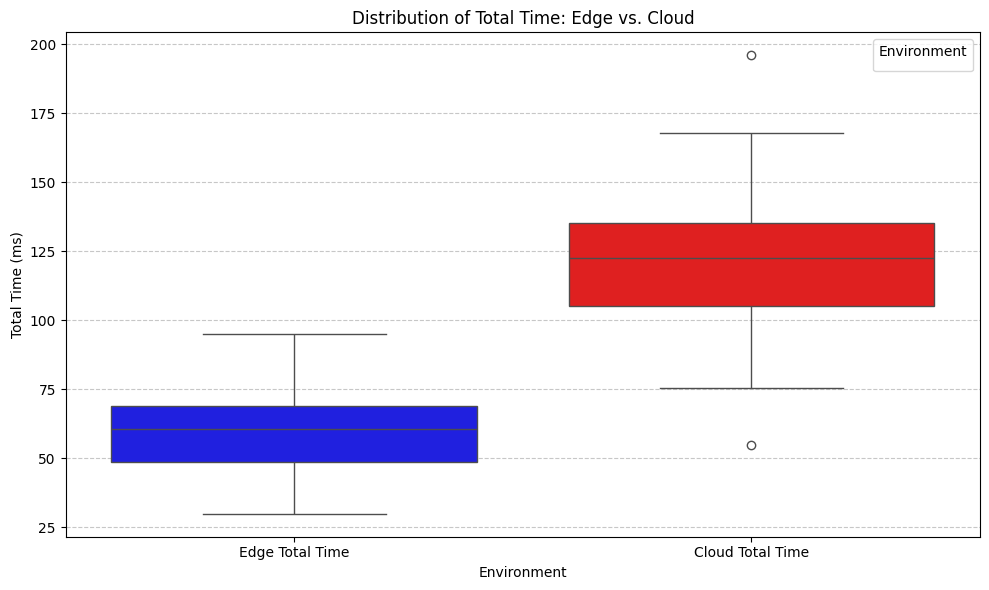

In [11]:
df_melted = df.melt(id_vars=['timestamp', 'workload_size'],
                     value_vars=['edge_total_time', 'cloud_total_time'],
                     var_name='environment',
                     value_name='total_time')

plt.figure(figsize=(10, 6))
sns.boxplot(x='environment', y='total_time', data=df_melted, hue='environment', palette={'edge_total_time': 'blue', 'cloud_total_time': 'red'})
plt.title('Distribution of Total Time: Edge vs. Cloud')
plt.xlabel('Environment')
plt.ylabel('Total Time (ms)')
plt.xticks(ticks=[0, 1], labels=['Edge Total Time', 'Cloud Total Time'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Environment')
plt.tight_layout()
plt.show()

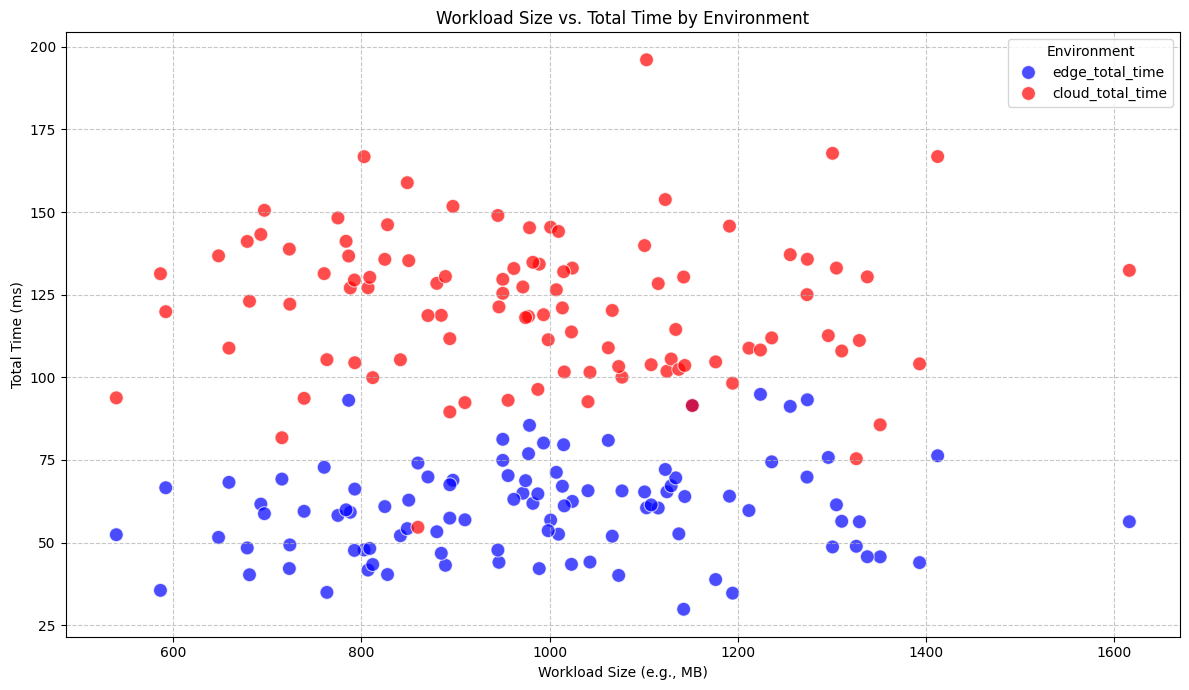

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='workload_size', y='total_time', hue='environment', data=df_melted, palette={'edge_total_time': 'blue', 'cloud_total_time': 'red'}, alpha=0.7, s=100)

plt.title('Workload Size vs. Total Time by Environment')
plt.xlabel('Workload Size (e.g., MB)')
plt.ylabel('Total Time (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Environment')
plt.tight_layout()
plt.show()

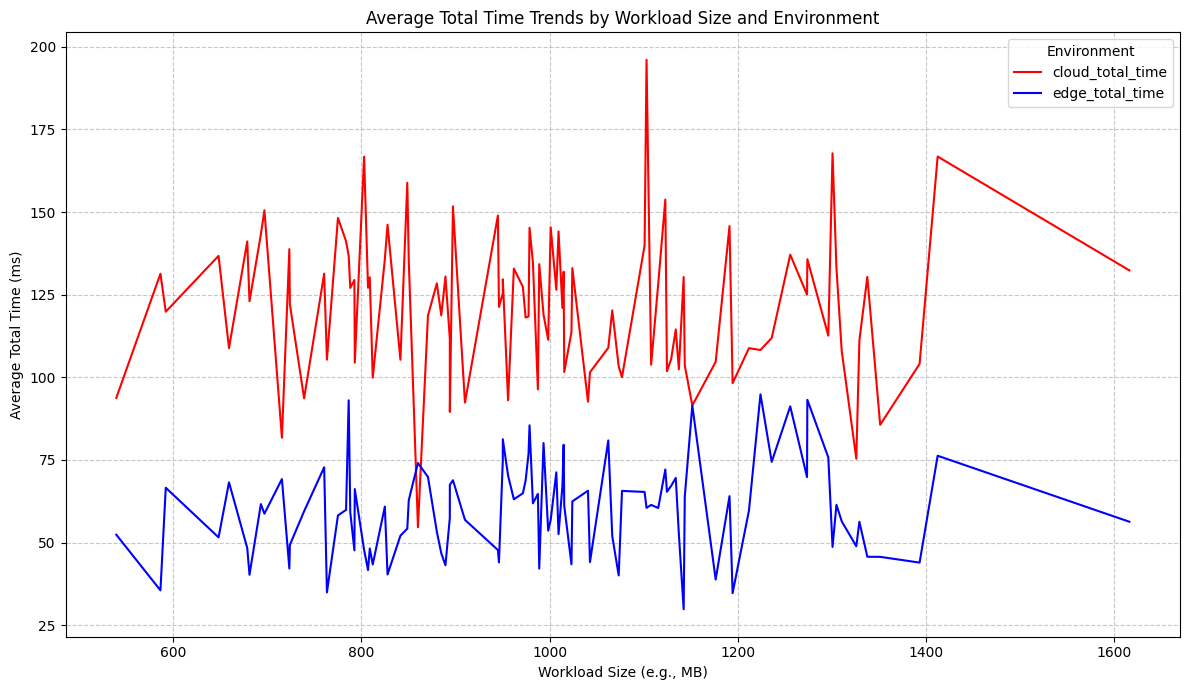

In [13]:
avg_total_time_by_workload = df_melted.groupby(['workload_size', 'environment'])['total_time'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='workload_size', y='total_time', hue='environment', data=avg_total_time_by_workload,
             palette={'edge_total_time': 'blue', 'cloud_total_time': 'red'})

plt.title('Average Total Time Trends by Workload Size and Environment')
plt.xlabel('Workload Size (e.g., MB)')
plt.ylabel('Average Total Time (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Environment')
plt.tight_layout()
plt.show()

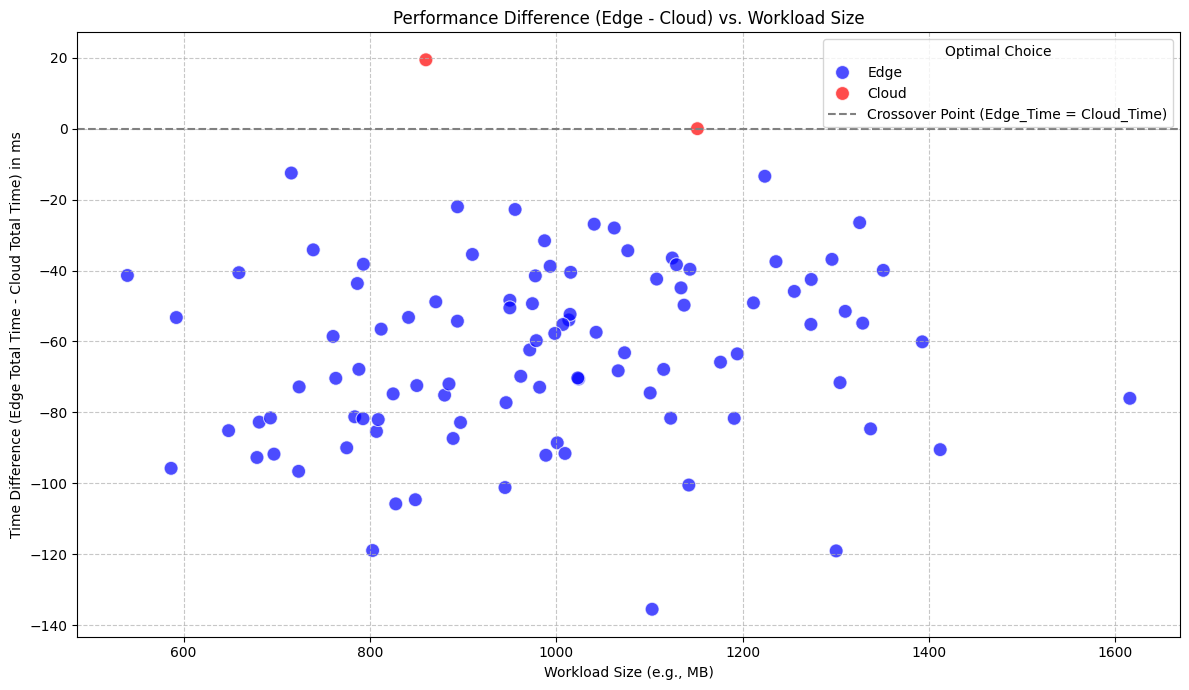

In [14]:
df['time_difference'] = df['edge_total_time'] - df['cloud_total_time']

plt.figure(figsize=(12, 7))
sns.scatterplot(x='workload_size', y='time_difference', data=df, hue='optimal_choice', palette={'Edge': 'blue', 'Cloud': 'red'}, s=100, alpha=0.7)
plt.axhline(y=0, color='grey', linestyle='--', label='Crossover Point (Edge_Time = Cloud_Time)')

plt.title('Performance Difference (Edge - Cloud) vs. Workload Size')
plt.xlabel('Workload Size (e.g., MB)')
plt.ylabel('Time Difference (Edge Total Time - Cloud Total Time) in ms')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Optimal Choice')
plt.tight_layout()
plt.show()

This plot directly visualizes the performance difference:

*   **Points below the grey line (y=0)**: Indicate that `edge_total_time` is *less* than `cloud_total_time`, meaning **Edge is faster**. These points are predominantly blue, aligning with the 'Edge' optimal choice.
*   **Points above the grey line (y=0)**: Indicate that `edge_total_time` is *greater* than `cloud_total_time`, meaning **Cloud is faster**. These points are predominantly red, aligning with the 'Cloud' optimal choice.

The **crossover point** is where the data points transition from being mostly below the line to mostly above it. From this visualization, we can observe that for `workload_size` values roughly around 1000-1200 MB, the optimal choice begins to shift from Edge to Cloud. This provides a clear visual threshold for adaptive decision-making.

### Regression Analysis: Workload Size vs. Total Time with Regression Lines

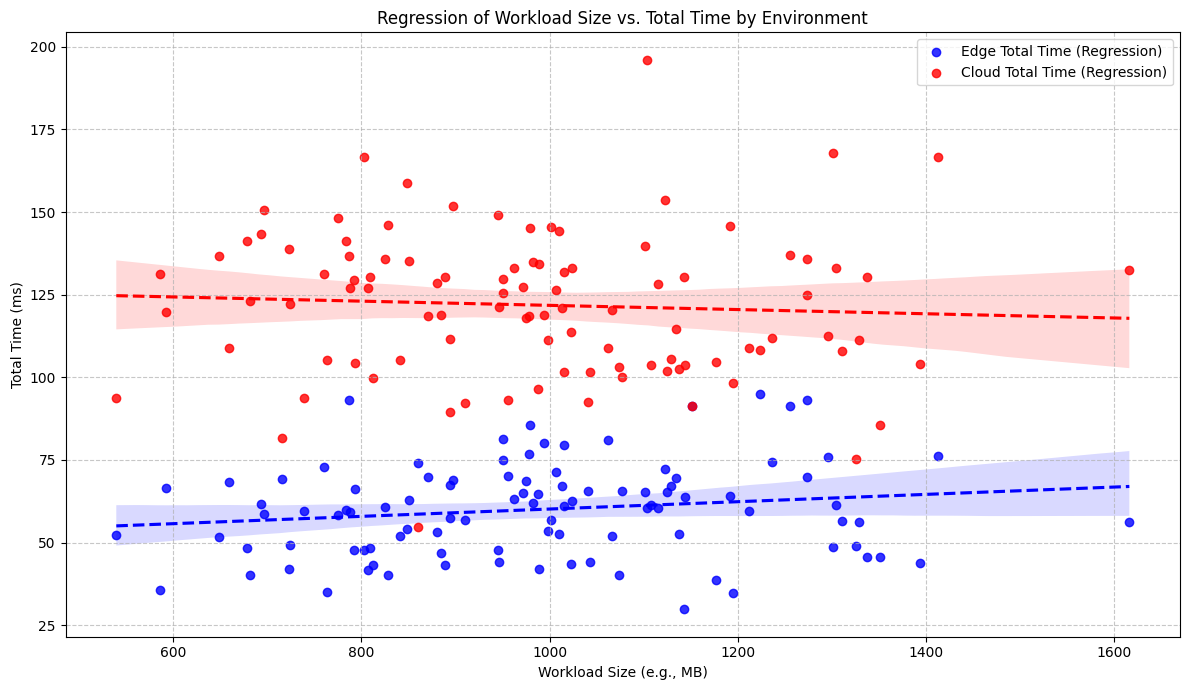

In [15]:
plt.figure(figsize=(12, 7))

sns.regplot(x='workload_size', y='total_time', data=df_melted[df_melted['environment'] == 'edge_total_time'],
            scatter=True, color='blue', label='Edge Total Time (Regression)',
            line_kws={'linestyle':'--'})
sns.regplot(x='workload_size', y='total_time', data=df_melted[df_melted['environment'] == 'cloud_total_time'],
            scatter=True, color='red', label='Cloud Total Time (Regression)',
            line_kws={'linestyle':'--'})

plt.title('Regression of Workload Size vs. Total Time by Environment')
plt.xlabel('Workload Size (e.g., MB)')
plt.ylabel('Total Time (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Summary Table: Edge vs. Cloud Performance Metrics

In [16]:
summary_stats = df[['edge_total_time', 'cloud_total_time']].agg(['mean', 'median', 'std']).T
summary_stats.columns = ['Mean Total Time (ms)', 'Median Total Time (ms)', 'Std Dev Total Time (ms)']
display(summary_stats)

,Mean Total Time (ms),Median Total Time (ms),Std Dev Total Time (ms)
edge_total_time,60.023029,60.483580,14.192359
cloud_total_time,121.832126,122.566465,22.130498


This table provides a quantitative summary of the performance differences:

*   **Mean Total Time**: The average total time for Edge is lower than Cloud in this simulation, suggesting that for the overall distribution of workloads, Edge often performs better. However, this average includes many instances where Edge is significantly faster, as well as those where Cloud overtakes it for larger workloads.

*   **Median Total Time**: The median further reinforces the average, indicating that the 'typical' workload completes faster on the Edge.

*   **Standard Deviation**: The standard deviation gives us insight into the variability. A lower standard deviation for Edge suggests its performance is more consistent across different workloads within its optimal range. The higher standard deviation for Cloud indicates more variability, which could be due to its higher baseline latency that can be offset by superior processing for specific workloads.